# Nesterov Accelerated Gradient Descent Algorithm

Momentum variant that evaluates the gradient at a look-ahead point. (The original also had the weight/bias update-swap bug -- fixed here.)

In [1]:
import numpy as np
from gd_utils import load_xy, gradient_descent, plot_loss_curve, plot_error_surface


## Load data

In [2]:
x, y = load_xy('sgd_data.txt')
print(f'x shape = {x.shape}, y shape = {y.shape}')


x shape = (40,), y shape = (40,)


## Run Nesterov accelerated gradient descent

The gradient is evaluated at a *look-ahead* point (`w - lr*momentum`, `b - lr*momentum`) rather than at the current parameters, which gives the optimizer a chance to "correct course" before committing to a step.

In [3]:
result_mse = gradient_descent(x, y, epochs=500, batch_size=10, loss='mse',
                               variant='nesterov', lr=0.2, eta=0.5, seed=0, verbose_every=100)


[nesterov] epoch    0  loss = 0.050650
[nesterov] epoch  100  loss = 0.035699
[nesterov] epoch  200  loss = 0.035679
[nesterov] epoch  300  loss = 0.035679
[nesterov] epoch  400  loss = 0.035679
[nesterov] epoch  500  loss = 0.035679


In [4]:
result_ce = gradient_descent(x, y, epochs=500, batch_size=10, loss='cross_entropy',
                              variant='nesterov', lr=0.2, eta=0.5, seed=0, verbose_every=100)


[nesterov] epoch    0  loss = 0.247638
[nesterov] epoch  100  loss = 0.231283
[nesterov] epoch  200  loss = 0.231293
[nesterov] epoch  300  loss = 0.231288
[nesterov] epoch  400  loss = 0.231287
[nesterov] epoch  500  loss = 0.231286


## Loss curves and error surfaces

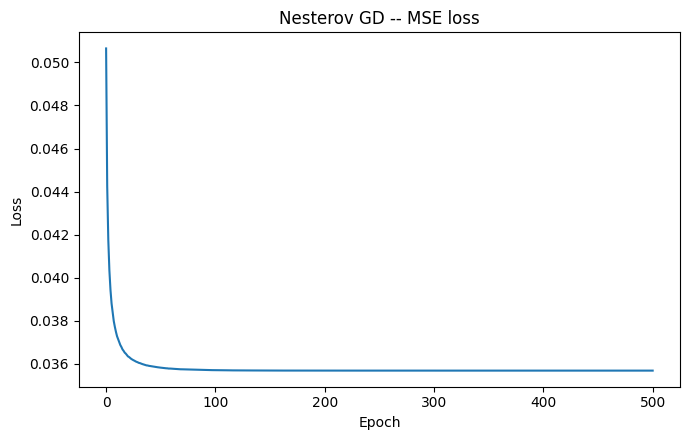

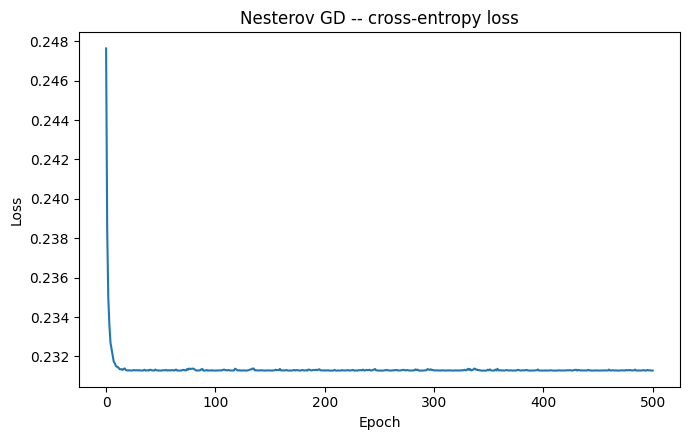

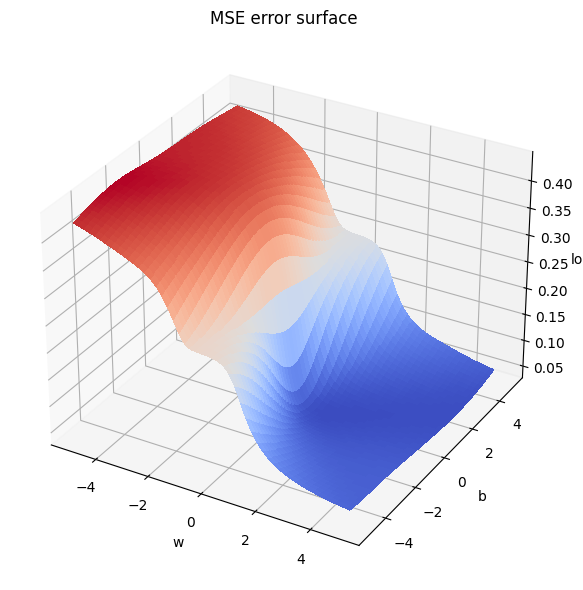

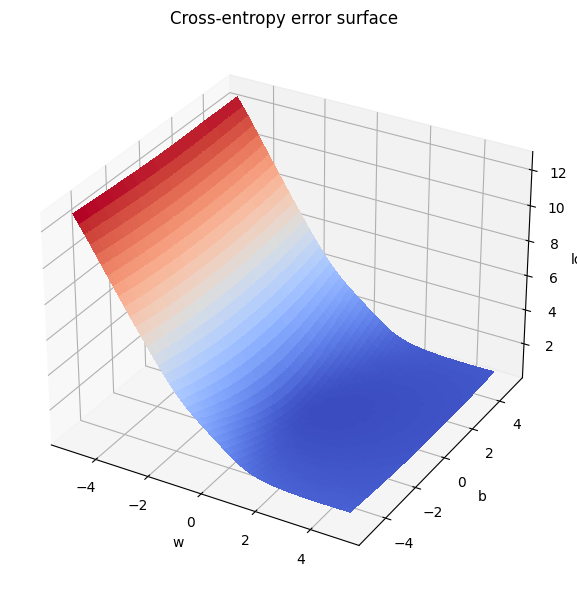

In [5]:
plot_loss_curve(result_mse, 'Nesterov GD -- MSE loss')
plot_loss_curve(result_ce, 'Nesterov GD -- cross-entropy loss')
plot_error_surface(x, y, loss='mse', w_range=(-5, 5), b_range=(-5, 5), num=150, title='MSE error surface')
plot_error_surface(x, y, loss='cross_entropy', w_range=(-5, 5), b_range=(-5, 5), num=150, title='Cross-entropy error surface')
